In [6]:
# Misc
import random
import numpy as np
import pandas as pd
import tqdm
from tqdm import tqdm
from tqdm import tqdm_notebook
import math
import os
import time
import sys
import json
# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
# Sklearn
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
# Pytorch
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F
# Keras 
import keras
# Helpers
# from Adverse import lowProFool, deepfool
# from Metrics import *
# 学習済みモデルを保存するために必要なライブラリのimport
import os
from datetime import datetime

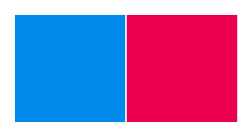

In [8]:
# Retina display
%config InlineBackend.figure_format ='retina'
pd.set_option('display.max_columns', 500)
tqdm.pandas()
np.set_printoptions(suppress=True)

%load_ext autoreload
%autoreload 2

ccolors = ["#008ae9", "#ea004f"]
sns.set_palette(ccolors)
sns.palplot(sns.color_palette())

In [27]:
SEED = 0

In [59]:
 dataset = fetch_openml('credit-g')
 dataset

{'data': array([[ 0.,  6.,  4., ...,  1.,  1.,  0.],
        [ 1., 48.,  2., ...,  1.,  0.,  0.],
        [ 3., 12.,  4., ...,  2.,  0.,  0.],
        ...,
        [ 3., 12.,  2., ...,  1.,  0.,  0.],
        [ 0., 45.,  2., ...,  1.,  1.,  0.],
        [ 1., 45.,  4., ...,  1.,  0.,  0.]]),
 'target': array(['good', 'bad', 'good', 'good', 'bad', 'good', 'good', 'good',
        'good', 'bad', 'bad', 'bad', 'good', 'bad', 'good', 'bad', 'good',
        'good', 'bad', 'good', 'good', 'good', 'good', 'good', 'good',
        'good', 'good', 'good', 'good', 'bad', 'good', 'good', 'good',
        'good', 'good', 'bad', 'good', 'bad', 'good', 'good', 'good',
        'good', 'good', 'good', 'bad', 'good', 'good', 'good', 'good',
        'good', 'good', 'good', 'good', 'good', 'bad', 'good', 'bad',
        'good', 'good', 'bad', 'good', 'good', 'bad', 'bad', 'good',
        'good', 'good', 'good', 'bad', 'good', 'good', 'good', 'good',
        'good', 'bad', 'good', 'bad', 'good', 'good', 'good

In [62]:
# Convert to DataFrame
target = 'target'
df = pd.DataFrame(data= np.c_[dataset['data'], dataset[target]], columns= dataset['feature_names'] + [target])  
df

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,0,6,4,3,1169,4,4,4,2,0,4,0,67,2,1,2,2,1,1,0,good
1,1,48,2,3,5951,0,2,2,1,0,2,0,22,2,1,1,2,1,0,0,bad
2,3,12,4,6,2096,0,3,2,2,0,3,0,49,2,1,1,1,2,0,0,good
3,0,42,2,2,7882,0,3,2,2,2,4,1,45,2,2,1,2,2,0,0,good
4,0,24,3,0,4870,0,2,3,2,0,4,3,53,2,2,2,2,2,0,0,bad
5,3,36,2,6,9055,4,2,2,2,0,4,3,35,2,2,1,1,2,1,0,good
6,3,24,2,2,2835,2,4,3,2,0,4,1,53,2,1,1,2,1,0,0,good
7,1,36,2,1,6948,0,2,2,2,0,2,2,35,2,0,1,3,1,1,0,good
8,3,12,2,3,3059,3,3,2,0,0,4,0,61,2,1,1,1,1,0,0,good
9,1,30,4,0,5234,0,0,4,3,0,2,2,28,2,1,2,3,1,0,0,bad


In [63]:
 df[target] = df[target].apply(lambda x: 0.0 if x == 'bad' or x == 0.0 else 1.0)
df

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,0,6,4,3,1169,4,4,4,2,0,4,0,67,2,1,2,2,1,1,0,1.0
1,1,48,2,3,5951,0,2,2,1,0,2,0,22,2,1,1,2,1,0,0,0.0
2,3,12,4,6,2096,0,3,2,2,0,3,0,49,2,1,1,1,2,0,0,1.0
3,0,42,2,2,7882,0,3,2,2,2,4,1,45,2,2,1,2,2,0,0,1.0
4,0,24,3,0,4870,0,2,3,2,0,4,3,53,2,2,2,2,2,0,0,0.0
5,3,36,2,6,9055,4,2,2,2,0,4,3,35,2,2,1,1,2,1,0,1.0
6,3,24,2,2,2835,2,4,3,2,0,4,1,53,2,1,1,2,1,0,0,1.0
7,1,36,2,1,6948,0,2,2,2,0,2,2,35,2,0,1,3,1,1,0,1.0
8,3,12,2,3,3059,3,3,2,0,0,4,0,61,2,1,1,1,1,0,0,1.0
9,1,30,4,0,5234,0,0,4,3,0,2,2,28,2,1,2,3,1,0,0,0.0


In [64]:
# Subsetting features to keep only continuous, discrete and ordered categorical
feature_names = ['checking_status', 'duration', 'credit_amount',
             'savings_status','employment','installment_commitment',
             'residence_since','age','existing_credits','num_dependents',
             'own_telephone','foreign_worker']

df = df[feature_names + [target]]
df

,checking_status,duration,credit_amount,savings_status,employment,installment_commitment,residence_since,age,existing_credits,num_dependents,own_telephone,foreign_worker,target
0,0,6,1169,4,4,4,4,67,2,1,1,0,1.0
1,1,48,5951,0,2,2,2,22,1,1,0,0,0.0
2,3,12,2096,0,3,2,3,49,1,2,0,0,1.0
3,0,42,7882,0,3,2,4,45,1,2,0,0,1.0
4,0,24,4870,0,2,3,4,53,2,2,0,0,0.0
5,3,36,9055,4,2,2,4,35,1,2,1,0,1.0
6,3,24,2835,2,4,3,4,53,1,1,0,0,1.0
7,1,36,6948,0,2,2,2,35,1,1,1,0,1.0
8,3,12,3059,3,3,2,4,61,1,1,0,0,1.0
9,1,30,5234,0,0,4,2,28,2,1,0,0,0.0


In [65]:
# Casting to float for later purpose
df = df.astype(float)
df

,checking_status,duration,credit_amount,savings_status,employment,installment_commitment,residence_since,age,existing_credits,num_dependents,own_telephone,foreign_worker,target
0,0.0,6.0,1169.0,4.0,4.0,4.0,4.0,67.0,2.0,1.0,1.0,0.0,1.0
1,1.0,48.0,5951.0,0.0,2.0,2.0,2.0,22.0,1.0,1.0,0.0,0.0,0.0
2,3.0,12.0,2096.0,0.0,3.0,2.0,3.0,49.0,1.0,2.0,0.0,0.0,1.0
3,0.0,42.0,7882.0,0.0,3.0,2.0,4.0,45.0,1.0,2.0,0.0,0.0,1.0
4,0.0,24.0,4870.0,0.0,2.0,3.0,4.0,53.0,2.0,2.0,0.0,0.0,0.0
5,3.0,36.0,9055.0,4.0,2.0,2.0,4.0,35.0,1.0,2.0,1.0,0.0,1.0
6,3.0,24.0,2835.0,2.0,4.0,3.0,4.0,53.0,1.0,1.0,0.0,0.0,1.0
7,1.0,36.0,6948.0,0.0,2.0,2.0,2.0,35.0,1.0,1.0,1.0,0.0,1.0
8,3.0,12.0,3059.0,3.0,3.0,2.0,4.0,61.0,1.0,1.0,0.0,0.0,1.0
9,1.0,30.0,5234.0,0.0,0.0,4.0,2.0,28.0,2.0,1.0,0.0,0.0,0.0


In [66]:
!sklearn -v

/usr/bin/sh: 1: sklearn: not found


In [67]:
X_num, y = fetch_openml('credit-g', version=1, as_frame=True, return_X_y=True)
X_cat = pd.read_csv('categorical_data.csv')

TypeError: fetch_openml() got an unexpected keyword argument 'as_frame'

In [68]:
!ls -al .

total 132
drwxr-xr-x  4 root root   128 Jan  9 13:25 .
drwxr-xr-x 18 root root   576 Jan  9 12:43 ..
drwxr-xr-x  4 root root   128 Dec 28 18:14 data
-rw-r--r--  1 root root 84846 Jan  9 13:34 output.csv


In [69]:
df.to_csv('output.csv', index=False, encoding='utf-8-sig')